In [ ]:
!pip install torch torchvision

import os, zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
from PIL import Image

In [ ]:
from google.colab import files
files.upload()   # upload subset_dataset.zip

In [ ]:
zip_name = [f for f in os.listdir() if f.endswith('.zip')][0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("dataset")

print(os.listdir("dataset"))

In [ ]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
full_ds = datasets.ImageFolder("dataset", transform=train_tf)

val_size = int(0.2 * len(full_ds))
train_size = len(full_ds) - val_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size])
val_ds.dataset.transform = val_tf

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

classes = full_ds.classes
print("Classes:", classes)

Classes: ['fake', 'real']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

best_acc = 0

for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1} Accuracy: {acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "cnn_best.pth")

print("Best Accuracy:", best_acc)

Epoch 1 Accuracy: 81.25%
Epoch 2 Accuracy: 81.25%
Epoch 3 Accuracy: 81.25%
Epoch 4 Accuracy: 87.50%
Epoch 5 Accuracy: 81.25%
Best Accuracy: 87.5


In [ ]:
from PIL import Image

def predict(img_path):
    img = Image.open(img_path).convert("RGB")
    img = val_tf(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(img)
        _, pred = torch.max(out, 1)

    return classes[pred.item()]

In [ ]:
from google.colab import files
uploaded = files.upload()

MessageError: TypeError: Cannot read properties of undefined (reading 'next')

In [ ]:
img_name = list(uploaded.keys())[0]
print("Prediction:", predict(img_name))

Prediction: real


Prediction: real


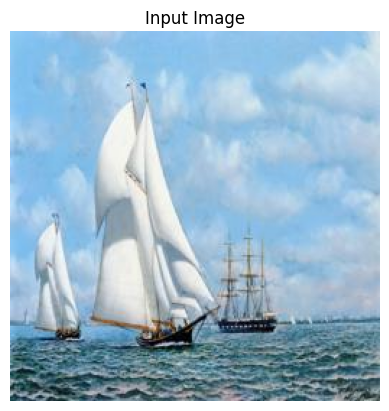

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(img_name)
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")

print("Prediction:", predict(img_name))

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import torch

def run_prototype():
    print("📤 Upload an image (real or fake):")

    uploaded = files.upload()
    img_name = list(uploaded.keys())[0]

    # Show image
    img = Image.open(img_name).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # Prediction
    model.eval()
    img_tensor = val_tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

    result = classes[pred.item()]

    print("\n🔍 Prediction:", result.upper())

📤 Upload an image (real or fake):


Saving fakeimagedeepfake.jpg to fakeimagedeepfake (1).jpg


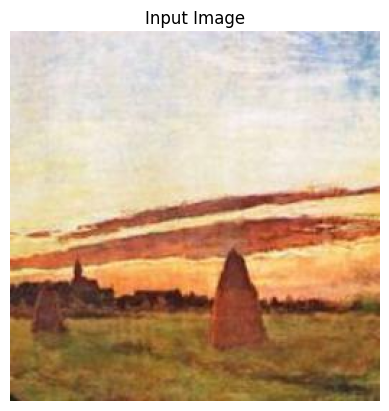


🔍 Prediction: FAKE


In [ ]:
run_prototype()